In [1]:
%pip install torchmetrics
!pip install torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [2]:
import os
import random
import torch
import numpy as np
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split, Subset
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.classification import MulticlassAccuracy
import torch.optim as optim
from tqdm import tqdm
import time
from torchinfo import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset

In [3]:
# Load dataset
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
val_ratio = 0.1
generator = torch.Generator().manual_seed(seed)
use_reduced_data = True

transform = transforms.Compose([
    transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation((-30, 30)),
    # transforms.ColorJitter(),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transformTest = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

CIFAR10Dataset = torchvision.datasets.CIFAR10(root='.', download=True)
full_train_dataset = torchvision.datasets.CIFAR10(root='.', train=True, download=True, transform=None)
test_dataset = torchvision.datasets.CIFAR10(root='.', train=False, download=True, transform=transformTest)

if use_reduced_data:
    total_reduced_size = 10000
    selected_indices = torch.randperm(len(full_train_dataset), generator=generator)[:total_reduced_size]
else:
    selected_indices = torch.arange(len(full_train_dataset))

val_size = int(len(selected_indices) * val_ratio)
train_size = len(selected_indices) - val_size
train_indices, val_indices = random_split(selected_indices, [train_size, val_size], generator=generator)


train_dataset = Subset(
    torchvision.datasets.CIFAR10(root='.', train=True, download=False, transform=transform),
    train_indices.indices
)

val_dataset = Subset(
    torchvision.datasets.CIFAR10(root='.', train=True, download=False, transform=transformTest),
    val_indices.indices
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=os.cpu_count())
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=os.cpu_count())
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=os.cpu_count())

100%|██████████| 170M/170M [00:04<00:00, 40.2MB/s]


# Pretrained model MobileNet

In [4]:
import torch.nn as nn
from torchvision.models import mobilenet_v3_large

def get_mobilenetv3(num_classes=10):
    model = mobilenet_v3_large(pretrained=True)

    # Adjust first conv stride for 32x32 input
    model.features[0][0].stride = (1, 1)

    # Freeze all layers initially
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last half of features (features[8:] since total 17 blocks) + classifier
    for i in range(8, len(model.features)):
        for param in model.features[i].parameters():
            param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

    # Replace final classification layer
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model
mobilenet_model = get_mobilenetv3().to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 135MB/s] 


# Small CNN

In [5]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SmallCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*64, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
student = SmallCNN().to(device)

# Train and Validation

In [6]:
def train(model, train_loader, val_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    model.to(device)
    results = []
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        start_time = time.time()

        for inputs, labels in (train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        val_acc, val_loss = validation(model, val_loader, device, show_metrics=False)
        scheduler.step()
        print(f"Epoch {epoch+1}/{epochs}({time.time() - start_time:.2f}s)  - accuracy: {train_acc:.4f}  - loss: {train_loss:.4f}  - val_accuracy: {val_acc:.4f}  - val_loss: {val_loss:.4f}")
        results.append([train_acc, train_loss, val_acc, val_loss])
    return results

def validation(model, test_loader, device, show_metrics=True):
    metric = MulticlassAccuracy(num_classes=10).to(device)
    model.eval()
    model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in (test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            metric.update(outputs, labels)
            total_loss += loss.item()

    accuracy_val = metric.compute().item()
    avg_loss = total_loss / len(test_loader)

    if show_metrics:
        print(f"Validation Accuracy: {accuracy_val:.4f} Loss: {avg_loss:.4f}")
    return accuracy_val, avg_loss


def train_knowledge_distillation(teacher, student, train_loader, val_loader, epochs, learning_rate, T, alpha, device):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(student.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    teacher.eval()  # Teacher set to evaluation mode
    student.train() # Student to train mode

    results = []

    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        start_time = time.time()
        for inputs, labels in (train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.no_grad():
                teacher_logits = teacher(inputs)
            student_logits = student(inputs)

            label_loss = criterion(student_logits, labels)
            soft_prob = nn.functional.log_softmax(student_logits / T, dim=-1)
            soft_targets = nn.functional.softmax(teacher_logits / T, dim=-1)
            soft_targets_loss = F.kl_div(soft_prob, soft_targets, reduction='batchmean') * (T ** 2)
            loss = alpha * soft_targets_loss + (1 - alpha) * label_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(student_logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        val_acc, val_loss = validation(student, val_loader, device, show_metrics=False)
        scheduler.step()
        print(f"Epoch {epoch+1}/{epochs}({time.time() - start_time:.2f}s) - accuracy: {train_acc:.4f}  - loss: {train_loss:.4f}  - val_accuracy: {val_acc:.4f}  - val_loss: {val_loss:.4f}")
        results.append([train_acc, train_loss, val_acc, val_loss])
    return results


# Train mobilenet_model

In [7]:
epochs = 30
learning_rate = 1e-3
history_mobilenet = train(mobilenet_model, train_loader, val_loader, epochs, learning_rate, device)
validation(mobilenet_model, test_loader, device)

Epoch 1/30(12.45s)  - accuracy: 0.4662  - loss: 1.7066  - val_accuracy: 0.6063  - val_loss: 1.4683
Epoch 2/30(10.86s)  - accuracy: 0.6244  - loss: 1.3433  - val_accuracy: 0.7231  - val_loss: 1.1687
Epoch 3/30(11.12s)  - accuracy: 0.6873  - loss: 1.2247  - val_accuracy: 0.7401  - val_loss: 1.1115
Epoch 4/30(11.24s)  - accuracy: 0.7081  - loss: 1.1680  - val_accuracy: 0.7707  - val_loss: 1.0429
Epoch 5/30(11.92s)  - accuracy: 0.7328  - loss: 1.1139  - val_accuracy: 0.7688  - val_loss: 1.0360
Epoch 6/30(11.23s)  - accuracy: 0.7468  - loss: 1.0842  - val_accuracy: 0.7695  - val_loss: 1.0375
Epoch 7/30(11.27s)  - accuracy: 0.7619  - loss: 1.0462  - val_accuracy: 0.8082  - val_loss: 0.9702
Epoch 8/30(11.20s)  - accuracy: 0.7772  - loss: 1.0139  - val_accuracy: 0.7787  - val_loss: 1.0001
Epoch 9/30(10.37s)  - accuracy: 0.7869  - loss: 0.9921  - val_accuracy: 0.8172  - val_loss: 0.9393
Epoch 10/30(11.05s)  - accuracy: 0.8083  - loss: 0.9526  - val_accuracy: 0.8048  - val_loss: 0.9689
Epoch 11/

(0.8362999558448792, 0.9025573540645041)

# Scratch Student training

In [8]:
scratch_student = SmallCNN().to(device)
history_scratch = train(scratch_student, train_loader, val_loader, epochs, learning_rate, device)
validation(scratch_student, test_loader, device)

Epoch 1/30(10.45s)  - accuracy: 0.3236  - loss: 1.9504  - val_accuracy: 0.4248  - val_loss: 1.7115
Epoch 2/30(9.78s)  - accuracy: 0.4126  - loss: 1.7745  - val_accuracy: 0.4773  - val_loss: 1.6167
Epoch 3/30(8.21s)  - accuracy: 0.4352  - loss: 1.7096  - val_accuracy: 0.5289  - val_loss: 1.5006
Epoch 4/30(8.98s)  - accuracy: 0.4748  - loss: 1.6524  - val_accuracy: 0.5566  - val_loss: 1.4579
Epoch 5/30(9.04s)  - accuracy: 0.4873  - loss: 1.6196  - val_accuracy: 0.5480  - val_loss: 1.5005
Epoch 6/30(8.13s)  - accuracy: 0.5044  - loss: 1.5817  - val_accuracy: 0.5810  - val_loss: 1.4176
Epoch 7/30(9.30s)  - accuracy: 0.5137  - loss: 1.5623  - val_accuracy: 0.5797  - val_loss: 1.4206
Epoch 8/30(8.96s)  - accuracy: 0.5384  - loss: 1.5323  - val_accuracy: 0.5925  - val_loss: 1.3819
Epoch 9/30(8.08s)  - accuracy: 0.5446  - loss: 1.5003  - val_accuracy: 0.6010  - val_loss: 1.3600
Epoch 10/30(9.08s)  - accuracy: 0.5533  - loss: 1.4907  - val_accuracy: 0.6237  - val_loss: 1.3144
Epoch 11/30(9.08s)

(0.6998000144958496, 1.1810441840985777)

# Knowledge Distillation

In [13]:
T, alpha = 4, 0.8

history_kd = train_knowledge_distillation(mobilenet_model, student, train_loader, val_loader, epochs, learning_rate, T=T, alpha=alpha, device=device)
validation(student, test_loader, device)

Epoch 1/30(8.63s) - accuracy: 0.5347  - loss: 1.1997  - val_accuracy: 0.6432  - val_loss: 1.2919
Epoch 2/30(10.88s) - accuracy: 0.5773  - loss: 1.0898  - val_accuracy: 0.6473  - val_loss: 1.2857
Epoch 3/30(9.95s) - accuracy: 0.6116  - loss: 1.0157  - val_accuracy: 0.6487  - val_loss: 1.3033
Epoch 4/30(9.79s) - accuracy: 0.6177  - loss: 0.9878  - val_accuracy: 0.6748  - val_loss: 1.2398
Epoch 5/30(9.13s) - accuracy: 0.6382  - loss: 0.9467  - val_accuracy: 0.6507  - val_loss: 1.2899
Epoch 6/30(9.34s) - accuracy: 0.6510  - loss: 0.9351  - val_accuracy: 0.6776  - val_loss: 1.2349
Epoch 7/30(9.73s) - accuracy: 0.6639  - loss: 0.9016  - val_accuracy: 0.6758  - val_loss: 1.2140
Epoch 8/30(9.85s) - accuracy: 0.6643  - loss: 0.8904  - val_accuracy: 0.6706  - val_loss: 1.2427
Epoch 9/30(9.47s) - accuracy: 0.6726  - loss: 0.8753  - val_accuracy: 0.6750  - val_loss: 1.2358
Epoch 10/30(9.34s) - accuracy: 0.6769  - loss: 0.8643  - val_accuracy: 0.6906  - val_loss: 1.2090
Epoch 11/30(9.87s) - accurac

(0.7235000133514404, 1.1643320773817172)

In [10]:
import matplotlib.pyplot as plt
def plot_history(history, title):
    # Unpack the history
    train_acc = [row[0] for row in history]
    train_loss = [row[1] for row in history]
    val_acc   = [row[2] for row in history]
    val_loss  = [row[3] for row in history]
    epochs = range(1, len(history) + 1)

    # Plotting
    plt.figure(figsize=(12, 5))

    # Subplot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)

    # Subplot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.suptitle(f'{title}', fontsize=16)
    plt.tight_layout()
    plt.show()


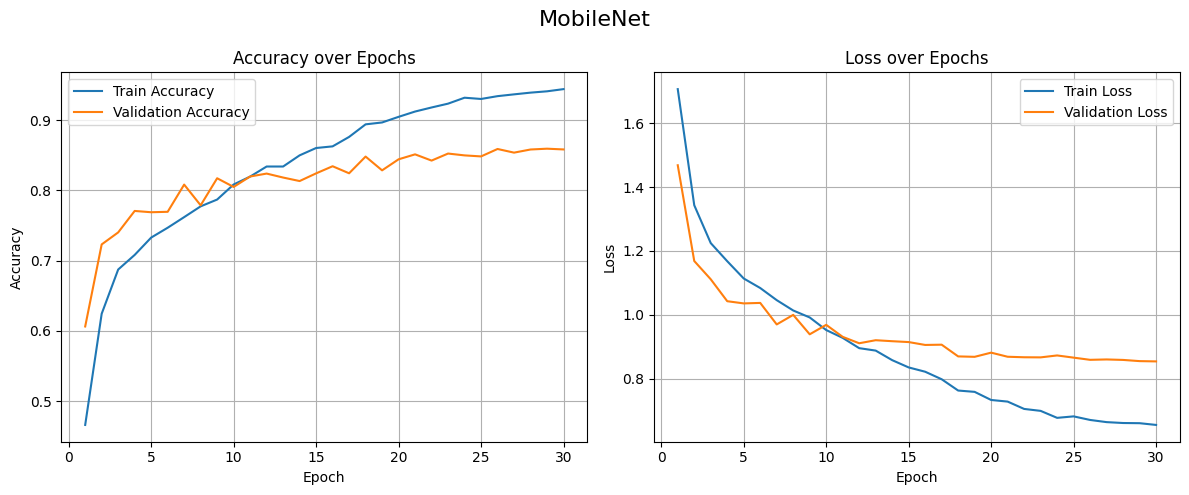

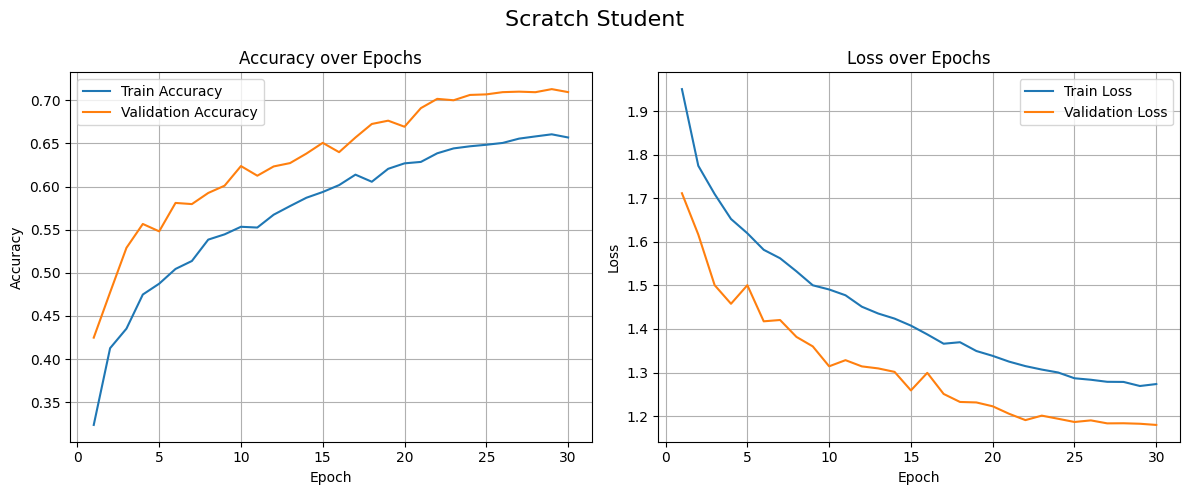

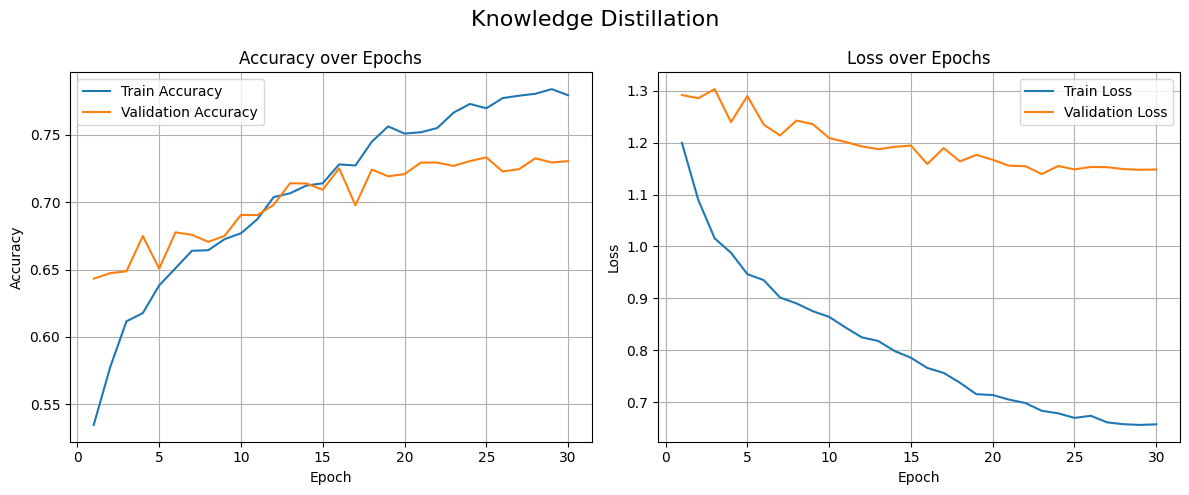

In [14]:
plot_history(history_mobilenet, 'MobileNet')
plot_history(history_scratch, 'Scratch Student')
plot_history(history_kd, 'Knowledge Distillation')